path 'C:\RESEARCH 2\STRIPE_1k_32\Stripe_X\StripeX-T-10.txt' exists


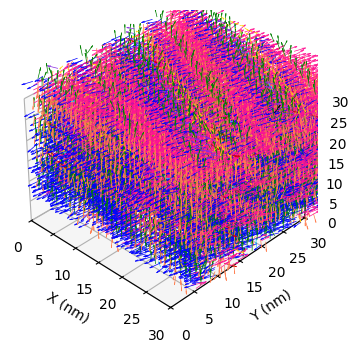

In [1]:
import matplotlib.pyplot as plt
import os

cwd = "C:\\RESEARCH 2\\STRIPE_1k_32\\Stripe_X\\"
file = "StripeX-T-10.txt" #change extension depending on whether file is .plt or .txt

path = f"{cwd}{file}"
if os.path.exists(path): # if input file exists, open and process it
    if file.endswith(".plt"):
        os.rename(path, f"{path[:-4]}.txt")
    path = f"{path[:-4]}.txt"
    print("path \'{}\' exists".format(path))
    fig = plt.figure(figsize=(5,4))
    ax = fig.add_subplot(projection='3d')
    #ax = fig.gca(projection='3d')
    read_file = open(path, "r")
    lines = read_file.readlines()
    x = 0
                    
    # processing lines in old stripe file
    for l in lines:
        flag = 0
        if len(l.split()) > 0:
            if l.split()[1] == "arrow": # if line contains component information
                # print(l.split()[len(l.split())-1])
                last = l.split()[len(l.split())-1]
                n = len(l.split())-1 + len(last.split(','))
                line_data = l.split()[:-1] + last.split(',')
                # print()
                # print(n)
                # print(line_data)
                row = []
                temp = []
                for i in range(n):
                    ass = line_data[i]
                    weenie = ass.split(',')
                    if len(weenie) == 2 and weenie[1] != '':
                        row.append(weenie[0])
                        row.append(weenie[1])
                    else:
                        row.append(weenie[0])
                x_comp = float(row[10]) - float(row[6]) 
                y_comp = float(row[11]) - float(row[7])
                z_comp = float(row[12]) - float(row[8]) 
                temp.append(float(row[6]))
                temp.append(float(row[7]))
                temp.append(float(row[8]))
                temp.append(x_comp)
                temp.append(y_comp)
                temp.append(z_comp)
                                    
                # assigning color value to different x y and z components
                if x_comp > 0 and y_comp > 0 and z_comp > 0: # x y z = + + +
                    temp.append("#FF1493") #pink
                if x_comp > 0 and y_comp > 0 and z_comp < 0: # x y z = + + -
                    temp.append("#CC0000") #red
                if x_comp > 0 and y_comp < 0 and z_comp < 0: # x y z = + - -
                    temp.append("#FF7F50") #orange
                if x_comp > 0 and y_comp < 0 and z_comp > 0: # x y z = + - +
                    temp.append("#FFD700") #yellow   
                if x_comp < 0 and y_comp > 0 and z_comp > 0: # x y z = - + +
                    temp.append("#008000") #green
                if x_comp < 0 and y_comp > 0 and z_comp < 0: # x y z = - + -
                    temp.append("#2ACAEA") #blue  
                if x_comp < 0 and y_comp < 0 and z_comp < 0: # x y z = - - -
                    temp.append("#0000FF") #dark blue
                if x_comp < 0 and y_comp < 0 and z_comp > 0: # x y z = - - +
                    temp.append("#8A2BE2") #purple
                else: #one of the components has a 0 value
                    temp.append("black")
                        
                # plots the respective vector
                ax.quiver([temp[0]], [temp[1]], [temp[2]], [temp[3]], [temp[4]], [temp[5]], colors=[temp[6]], length=1, linewidth=0.5)
                x += 1                    
            
    #change limits according to supercell size
    ax.set_xlim3d([0, 30])
    ax.set_xlabel('X (nm)')
            
    ax.set_ylim3d([0, 30])
    ax.set_ylabel('Y (nm)')
            
    ax.set_zlim3d([0, 30])
    ax.set_zlabel('Z (nm)')
            
    ax.view_init(elev=35, azim=-46)
    # ax.set_axis_off()
            
    plt.savefig("{}/StripeX{}.png".format(cwd, file[:-4]), dpi=600)
            
else:
    print("the path \'{}\' does not exist".format(path))




Using plane_z = 20.0


C:\Users\Neil Joshi\AppData\Local\Temp\ipykernel_26412\2678848893.py:90: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show(screenshot="StripeX T 10 3D unconventional_cones.png")


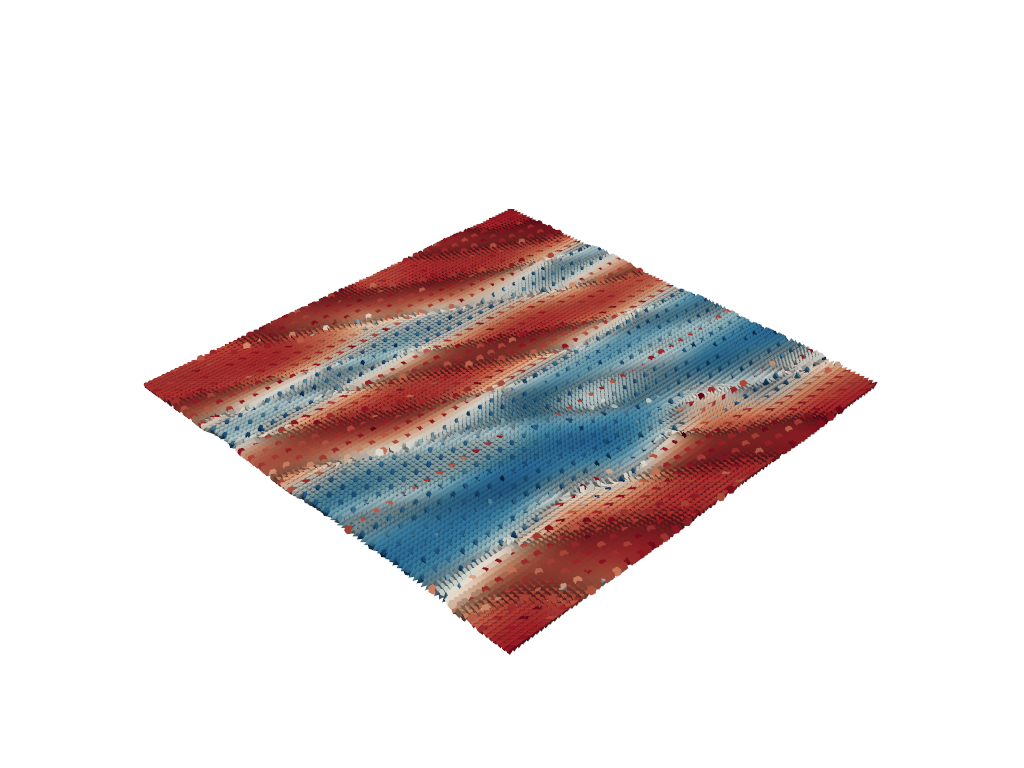

In [14]:
import pyvista as pv
import numpy as np

file = "C:\\RESEARCH 2\\STRIPE_1k_32\\Stripe_X\\StripeX-T-10.txt"

points = []
vectors = []

# First pass: collect all z values
z_values = []

with open(file) as f:
    for line in f:
        if "from" not in line:
            continue

        part = line.split("from")[1]
        start, _ = part.split("to")

        x1, y1, z1 = map(float, start.strip().split(","))
        z_values.append(z1)

# Choose most common z-plane
z_values = np.array(z_values)
plane_z = np.round(np.median(z_values), 2)

print("Using plane_z =", plane_z)

# Second pass: filter properly
with open(file) as f:
    for line in f:
        if "from" not in line:
            continue

        part = line.split("from")[1]
        start, end = part.split("to")

        x1,y1,z1 = map(float,start.strip().split(","))
        x2,y2,z2 = map(float,end.strip().split(","))

        if abs(z1-plane_z) > 1e-3:
            continue

        points.append([x1,y1,z1])
        vectors.append([x2-x1,y2-y1,z2-z1])

points = np.array(points)
vectors = np.array(vectors)

# safety check
if len(points) == 0:
    raise ValueError("No points found. Check data.")

# create mesh
mesh = pv.PolyData(points)
mesh["vec"] = vectors

# grid
xmin,xmax = points[:,0].min(), points[:,0].max()
ymin,ymax = points[:,1].min(), points[:,1].max()

nx, ny = 100, 100

x = np.linspace(xmin,xmax,nx)
y = np.linspace(ymin,ymax,ny)

xx,yy = np.meshgrid(x,y)
zz = np.full_like(xx,plane_z)

grid_points = np.c_[xx.ravel(),yy.ravel(),zz.ravel()]
grid = pv.PolyData(grid_points)

# interpolate
grid = grid.interpolate(mesh, radius=4)

# remove invalid vectors
mask = np.linalg.norm(grid["vec"], axis=1) > 0
grid = grid.extract_points(mask)

# glyphs
glyphs = grid.glyph(
    orient="vec",
    scale=False,
    factor=0.55,
    geom=pv.Cone()
)

plotter = pv.Plotter()
plotter.add_mesh(glyphs, cmap="RdBu", show_scalar_bar=False)
plotter.show(screenshot="StripeX T 10 3D unconventional_cones.png")